In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/sales.csv")
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [28]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [29]:
df.shape

(9800, 18)

In [30]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

## Data Understanding

- The dataset contains sales transaction data.
- Important columns include product, category, city, quantity, price, and order date.
- We will clean and analyze this data to find sales trends and business insights.

In [31]:
# Check missing values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [32]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

In [33]:
# Create new columns
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year
df['Day'] = df['Order Date'].dt.day

# Check missing values
df.isnull().sum()

Row ID              0
Order ID            0
Order Date       5841
Ship Date        5985
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code        11
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Month            5841
Year             5841
Day              5841
dtype: int64

In [34]:
# Check data again
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Month,Year,Day
0,1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,8.0,2017.0,11.0
1,2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,8.0,2017.0,11.0
2,3,CA-2017-138688,2017-12-06,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,12.0,2017.0,6.0
3,4,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,11.0,2016.0,10.0
4,5,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,11.0,2016.0,10.0


In [35]:
df = df.dropna()

In [36]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

In this step, the dataset was cleaned by performing the following operations:
- Converted Order Date and Ship Date to datetime format
- Created Month, Year and day columns for time-based analysis
- Verified that there are no missing values affecting analysis

Data cleaning is important to ensure accurate analysis and reliable results.

In [37]:
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 612548.3439


In [38]:
yearly_sales = df.groupby('Year')['Sales'].sum()
yearly_sales

Year
2015.0    109305.6880
2016.0    110361.5202
2017.0    196943.3494
2018.0    195937.7863
Name: Sales, dtype: float64

In [39]:
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales

Month
1.0      90957.9824
2.0     103951.1600
3.0      71788.6906
4.0      65094.9490
5.0      64072.0488
6.0      43589.7720
7.0      52971.2185
8.0      63874.7706
9.0      23855.9080
10.0     13095.9710
11.0     14585.2300
12.0      4710.6430
Name: Sales, dtype: float64

In [40]:
category_sales = df.groupby('Category')['Sales'].sum()
category_sales

Category
Furniture          191712.6749
Office Supplies    170036.1260
Technology         250799.5430
Name: Sales, dtype: float64

In [41]:
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
subcat_sales

Sub-Category
Chairs         87944.1700
Phones         81989.2580
Machines       74140.4570
Storage        53745.3960
Tables         53435.4935
Accessories    48060.4380
Copiers        46609.3900
Binders        42047.1360
Bookcases      26686.9254
Appliances     25046.9740
Furnishings    23646.0860
Paper          20647.4520
Supplies       11755.1760
Art             8674.5720
Envelopes       3799.4340
Labels          3543.0060
Fasteners        776.9800
Name: Sales, dtype: float64

In [42]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                          17499.950
Lexmark MX611dhe Monochrome Laser Printer                      11219.934
HP Designjet T520 Inkjet Large Format Printer - 24" Color       8749.950
Hewlett Packard LaserJet 3310 Copier                            8159.864
Cubify CubeX 3D Printer Triple Head Print                       7999.980
Global Deluxe High-Back Manager's Chair                         5948.384
Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back     5635.938
GBC DocuBind P400 Electric Binding System                       5443.960
Bady BDG101FRU Card Printer                                     5439.932
Canon Imageclass D680 Copier / Fax                              5319.924
Name: Sales, dtype: float64

In [43]:
region_sales = df.groupby('Region')['Sales'].sum()
region_sales

Region
Central    147409.9664
East       170389.5930
South      113827.5395
West       180921.2450
Name: Sales, dtype: float64

In [44]:
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
city_sales

City
New York City    73443.658
Los Angeles      47404.034
San Francisco    28229.595
Seattle          25284.120
Philadelphia     22579.257
Lafayette        18862.810
Houston          18097.188
San Antonio      14219.959
Henderson        13428.738
Arlington        11127.996
Name: Sales, dtype: float64

In [45]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_customers

Customer Name
Tamara Chand       18437.138
Becky Martin       11432.840
Grant Thornton      9351.212
Caroline Jumper     8989.494
Sanjit Engle        8805.040
Maria Etezadi       8081.148
Daniel Raglin       6937.870
Karen Ferguson      6903.054
Todd Sumrall        6646.038
Karen Daniels       6317.162
Name: Sales, dtype: float64

## Exploratory Data Analysis

The following analysis was performed:

- Calculated total sales
- Analyzed sales by year and month
- Analyzed sales by category and sub-category
- Identified top-selling products
- Identified top-performing regions and cities
- Identified top customers by sales

This analysis helps understand sales performance and business trends.

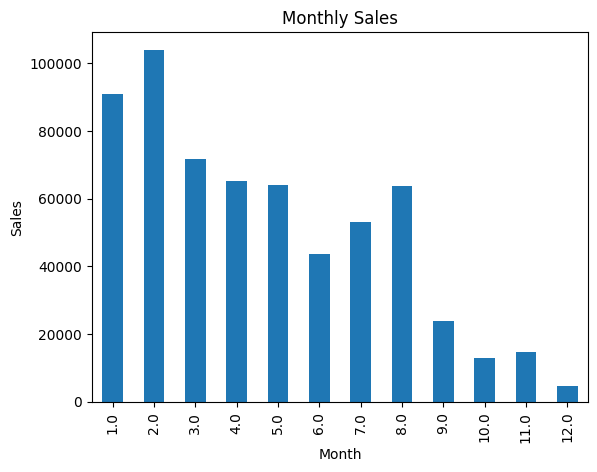

In [46]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind='bar')
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.savefig("../outputs/monthly_sales.png")
plt.show()


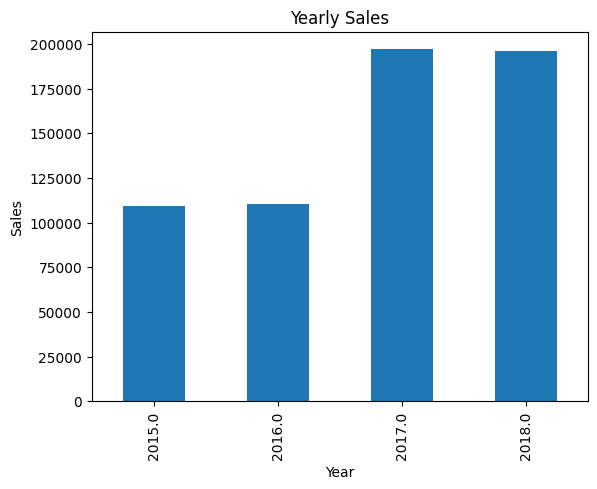

In [52]:
yearly_sales.plot(kind='bar')
plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.savefig("../outputs/yearly_sales.png")
plt.show()


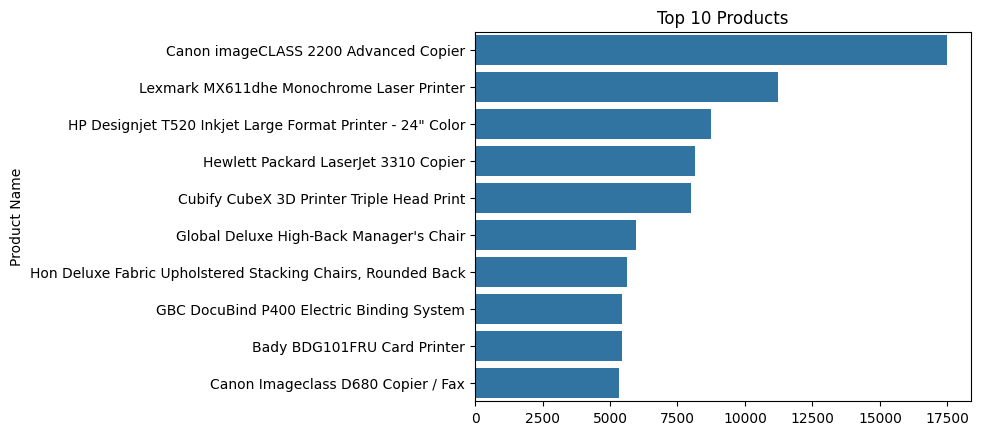

In [53]:
import seaborn as sns

sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products")
plt.savefig("../outputs/top_products.png")
plt.show()


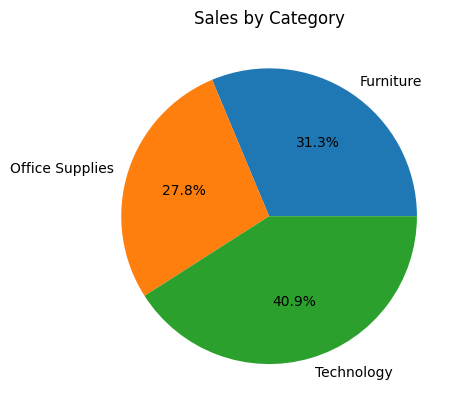

In [54]:
category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Category")
plt.savefig("../outputs/category_pie.png")
plt.show()


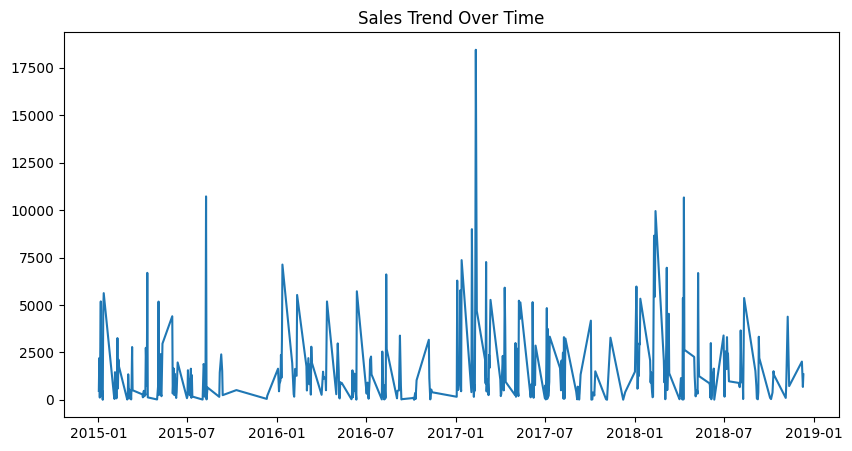

In [55]:
sales_trend = df.groupby('Order Date')['Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(sales_trend)
plt.title("Sales Trend Over Time")
plt.savefig("../outputs/sales_trend.png")
plt.show()


## Advanced Visualization

A correlation heatmap is used to understand relationships between numerical variables.

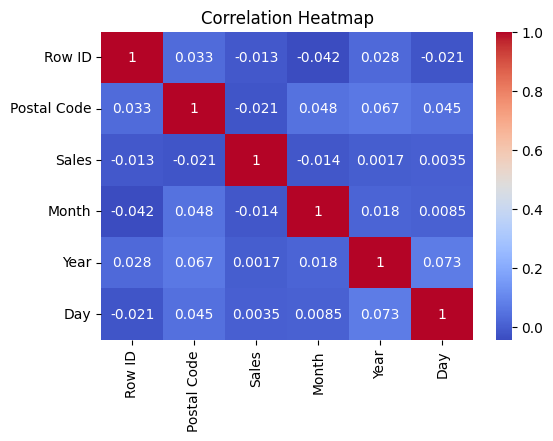

In [56]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("../outputs/heatmap.png")
plt.show()


### Insight

The heatmap shows the correlation between numerical features. Sales does not show strong correlation with other variables, indicating that multiple factors influence sales performance.

## Business Insights

- Technology category generates the highest sales.
- A small number of products contribute a large percentage of total revenue.
- Certain regions and cities have higher sales performance.
- Sales show seasonal trends across different months.
- Top customers contribute significantly to overall sales.

These insights can help businesses improve marketing strategies, inventory management, and sales planning.

## Conclusion

This project analyzed sales data using Python. Data cleaning, exploratory data analysis, and visualization were performed to identify important business insights. The analysis showed sales trends, top products, top regions, and customer behavior, which can help businesses make data-driven decisions.

## Future Work

- Sales prediction using Machine Learning
- Customer segmentation using clustering
- Profit prediction
- Dashboard creation using Plotly